In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.6 MB/s eta 0:00:00


In [2]:
!gdown --folder https://drive.google.com/drive/folders/13VOOlraECqGa6CdGW4miNCt9QbWfFakn?usp=drive_link

Retrieving folder contents
Processing file 1_q6wJHObwOk7CifpSeUiVLo2WXNGkof_ Deteccion_de_insumos_y_instrumentos_medicos.yolo26.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1_q6wJHObwOk7CifpSeUiVLo2WXNGkof_
From (redirected): https://drive.google.com/uc?id=1_q6wJHObwOk7CifpSeUiVLo2WXNGkof_&confirm=t&uuid=e1b189ac-74d2-4b22-afbc-163ea23834b5
To: /content/MedicalDataset/Deteccion_de_insumos_y_instrumentos_medicos.yolo26.zip
100% 666M/666M [00:12<00:00, 51.3MB/s]
Download completed


In [3]:
!unzip /content/MedicalDataset/Deteccion_de_insumos_y_instrumentos_medicos.yolo26.zip

Archive:  /content/MedicalDataset/Deteccion_de_insumos_y_instrumentos_medicos.yolo26.zip
 extracting: train/images/bisturi123_jpg.rf.Ip1JcU1mouE2ou7XC2EL.jpg  
 extracting: train/images/bisturi137_jpg.rf.MHUXJRN0F9PR0DtqRT2j.jpg  
 extracting: test/images/3SFGLDM5EZ1THY8KWA6Q_jpg.rf.AZXqJeMZx1ak4geotZNd.jpg  
 extracting: train/images/7K4W2NSC08ZLG5VMXJHF_jpg.rf.uvRNjHpsVcxHEu7AtipF.jpg  
 extracting: test/images/DSC_9928_JPG_JPG.rf.f91HcrkDrMWf6WBZpqnW.JPG  
 extracting: test/images/4Y9508CWOXKLUZE7QIM6_jpg.rf.J6O5ULGWIuErb1hZ3gr8.jpg  
 extracting: train/images/6CLMVZ53JPFNSQU24DY1_jpg.rf.pu5XV6LDhZT1AHDBKg3w.jpg  
 extracting: train/images/bisturi13_jpg.rf.MO1ZkTfNKb97GNR3yt0v.jpg  
 extracting: test/images/1OJ4U82WM3ZK0ANFRGY6_jpg.rf.USlORnJdoLw6spBmi40L.jpg  
 extracting: train/images/9PIURBVDM2YK8ZSXT04N_jpg.rf.x54oZALUC6Fi4R05wiyo.jpg  
 extracting: train/images/bisturi12_jpg.rf.PtxncT7VjbxfRQNOK5mN.jpg  
 extracting: train/images/bisturi127_jpg.rf.OrMzFVwbLV6PCyYMRgAZ.jpg  
 ex

In [4]:
#IMPORTACIÓN
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv
import torch
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
#CHEQUEO DE HADWARE
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponible. Usando:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU disponible. Usando CPU.")

GPU disponible. Usando: Tesla T4


In [6]:
#cargamos el modelo de yolo 26
model = YOLO("/content/yolo26n.pt")

#chequeamos que del modelo se encuentre todo bien
model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

In [7]:
#retoques del modelo para que pueda hacer un buen entrenamiento
#HIPERPARAMETROS
train_results = model.train(
    data="/content/data.yaml",
    epochs=100,
    imgsz=640,
    device=0,
    batch=16,
    optimizer='AdamW',
    lr0=0.001,        # bajado para AdamW
    patience=20,
    seed=42,
    mixup=0.1,
    copy_paste=0.1,   # ayuda al desbalance pegando instancias raras
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

In [8]:
# Cargar el mejor modelo
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Evaluar el modelo
metrics = model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2359.3±800.6 MB/s, size: 2542.3 KB)
val: Scanning /content/valid/labels.cache... 129 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 31.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.5s/it 13.6s
                   all        129        264      0.964      0.911      0.967      0.737
               Jeringa         19         19      0.949      0.981      0.993      0.618
          Tijera_recta         29         29          1      0.898      0.986      0.839
               bisturi         28         28      0.965      0.893      0.947      0.848
            mascarilla         33        158      0.904      0.861       0.92      0.583
 mascarilla-de-oxigeno         30         30         

In [ ]:
#----------A CONTINUACIÓN SE PRESENTAN LAS METRICAS RESULTANTES DEL AVANCE 3


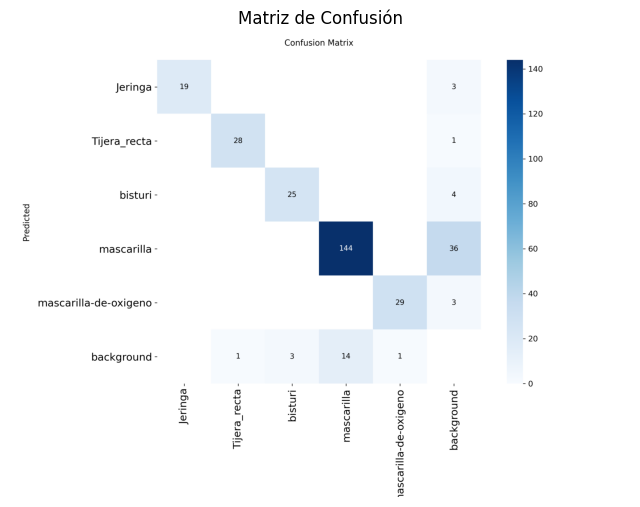

In [9]:
image_path = '/content/runs/detect/train/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

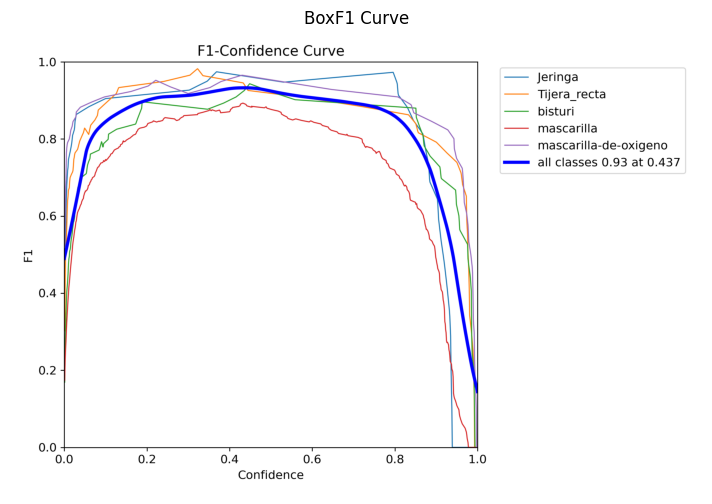

In [10]:
image_path = '/content/runs/detect/train/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

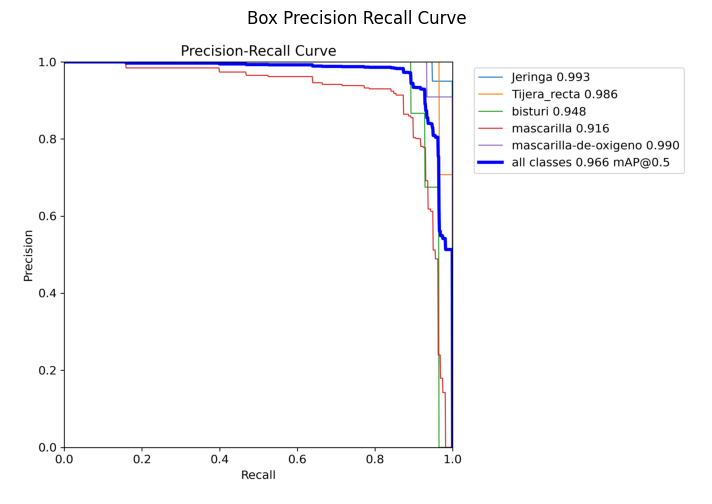

In [11]:
image_path = '/content/runs/detect/train/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

MÉTRICAS FINALES (última época)
Precision    : 0.9671
Recall       : 0.9155
mAP50        : 0.9662
mAP50-95     : 0.7381

Mejor época  : 100  (mAP50-95 = 0.7381)


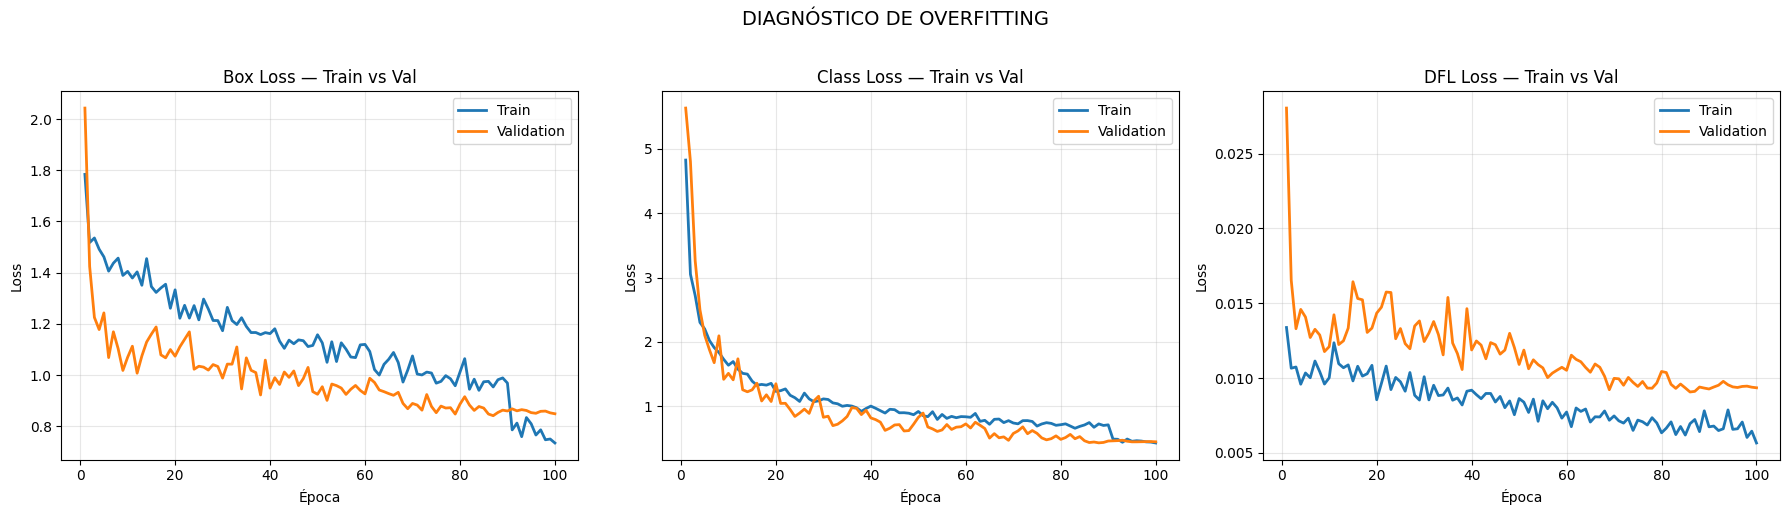


Gap val-train (cls_loss) al inicio: 0.8072
Gap val-train (cls_loss) al final : 0.0185
→ El gap se mantiene estable: sin señales claras de overfitting.


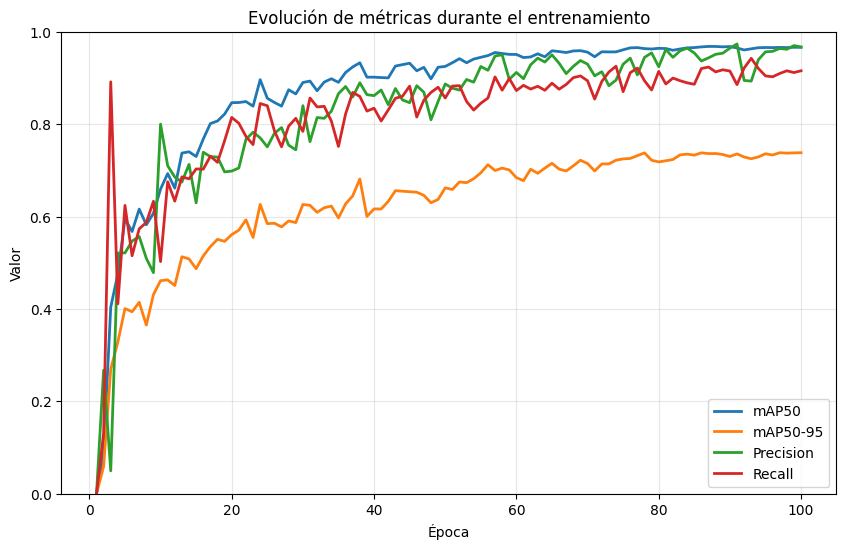

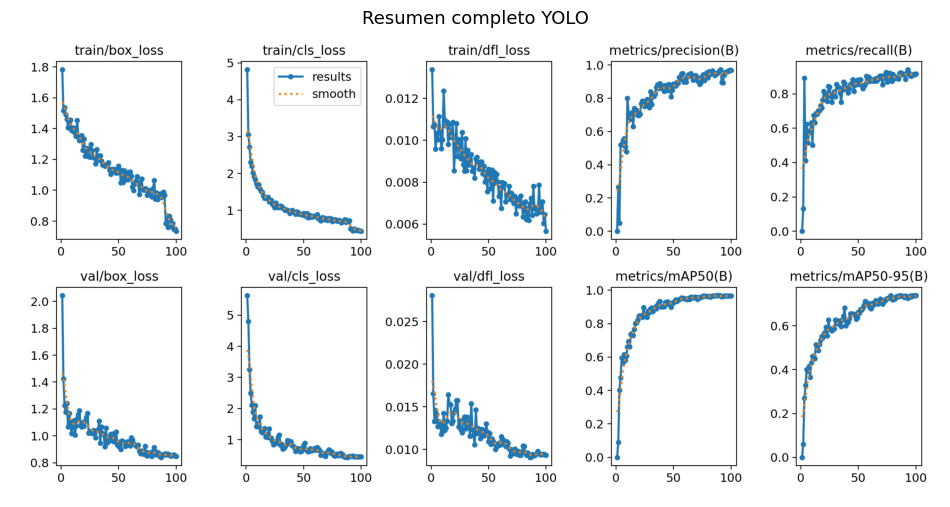

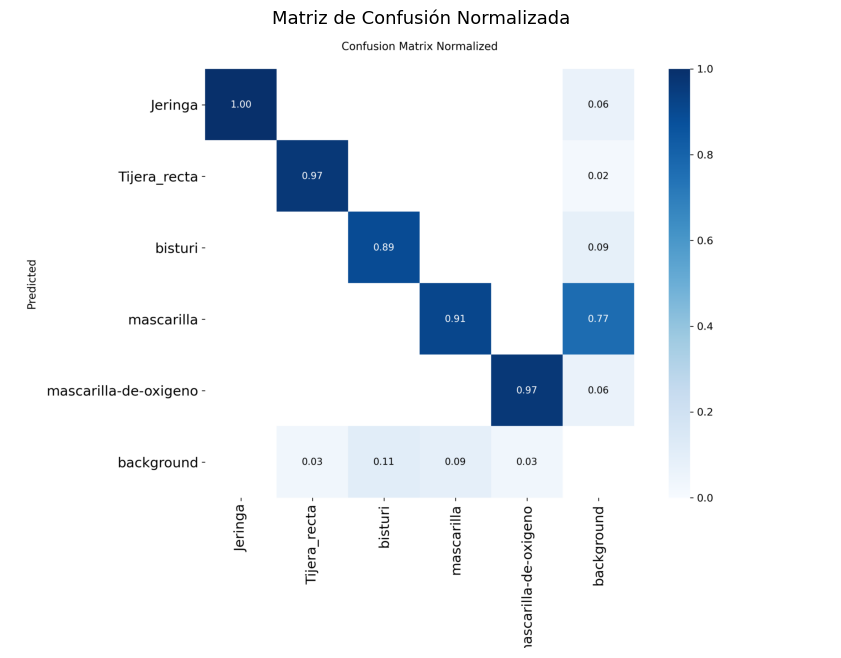

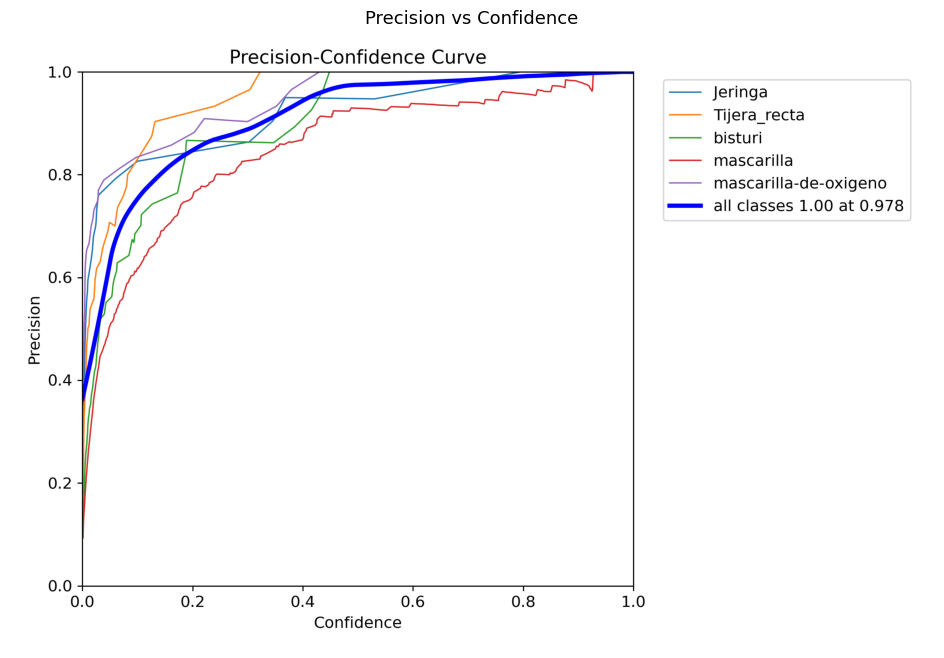

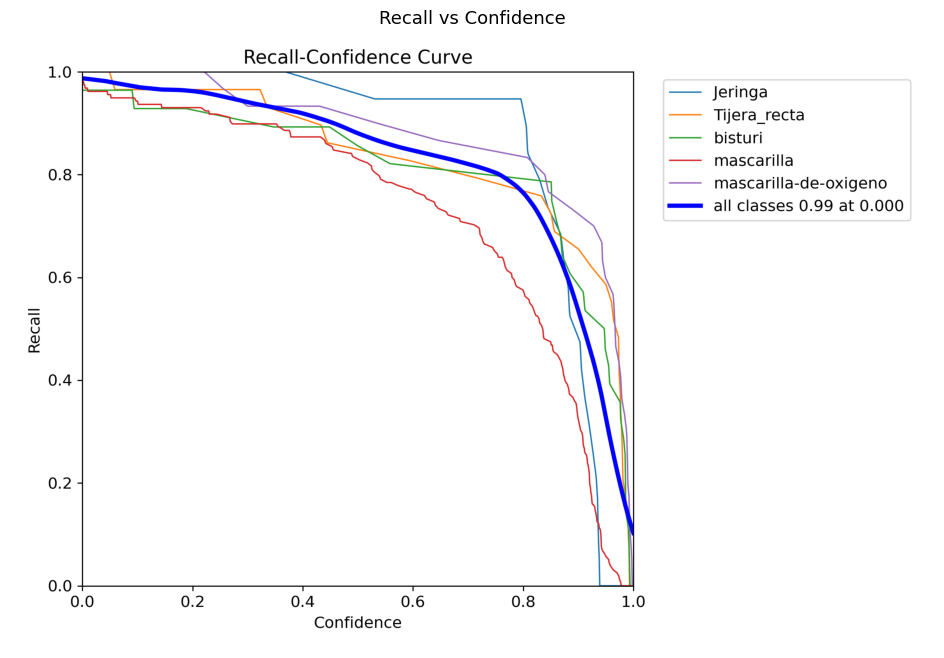

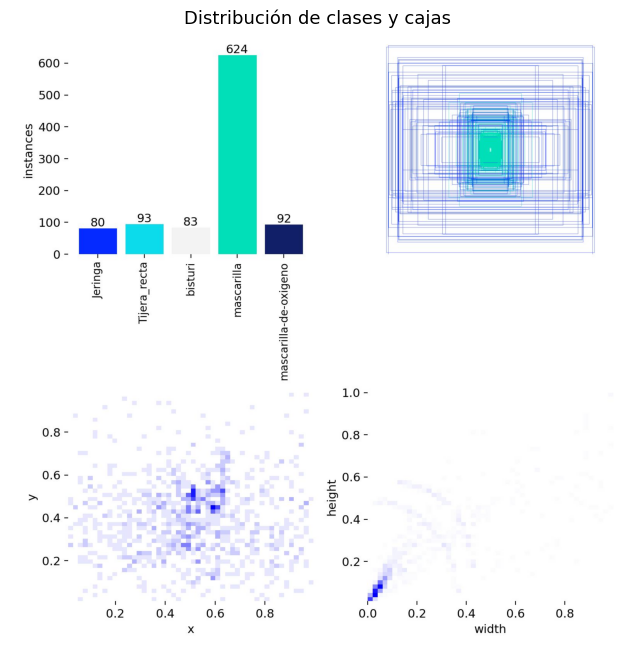

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

RUN = '/content/runs/detect/train'   # ajusta si guardaste en Drive

# =========================================================
# 1. TABLA DE MÉTRICAS FINALES (mAP50, mAP50-95, P, R)
# =========================================================
df = pd.read_csv(os.path.join(RUN, 'results.csv'))
df.columns = df.columns.str.strip()   # el csv trae espacios en los nombres

ultima = df.iloc[-1]
print("="*55)
print("MÉTRICAS FINALES (última época)")
print("="*55)
print(f"Precision    : {ultima['metrics/precision(B)']:.4f}")
print(f"Recall       : {ultima['metrics/recall(B)']:.4f}")
print(f"mAP50        : {ultima['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95     : {ultima['metrics/mAP50-95(B)']:.4f}")

# La MEJOR época (no siempre es la última, por el early stopping)
mejor = df.loc[df['metrics/mAP50-95(B)'].idxmax()]
print(f"\nMejor época  : {int(mejor['epoch'])}  (mAP50-95 = {mejor['metrics/mAP50-95(B)']:.4f})")
print("="*55)


# =========================================================
# 2. DIAGNÓSTICO DE OVERFITTING  (train loss vs val loss)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [('train/box_loss', 'val/box_loss', 'Box Loss'),
         ('train/cls_loss', 'val/cls_loss', 'Class Loss'),
         ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss')]

for ax, (tr, vl, titulo) in zip(axes, pares):
    ax.plot(df['epoch'], df[tr], label='Train', linewidth=2)
    ax.plot(df['epoch'], df[vl], label='Validation', linewidth=2)
    ax.set_xlabel('Época'); ax.set_ylabel('Loss')
    ax.set_title(f'{titulo} — Train vs Val')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('DIAGNÓSTICO DE OVERFITTING', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Lectura automática del gap
gap_ini = df['val/cls_loss'].iloc[0]  - df['train/cls_loss'].iloc[0]
gap_fin = df['val/cls_loss'].iloc[-1] - df['train/cls_loss'].iloc[-1]
print(f"\nGap val-train (cls_loss) al inicio: {gap_ini:.4f}")
print(f"Gap val-train (cls_loss) al final : {gap_fin:.4f}")
if gap_fin > gap_ini * 1.5:
    print("→ El gap creció: posible OVERFITTING.")
else:
    print("→ El gap se mantiene estable: sin señales claras de overfitting.")


# =========================================================
# 3. EVOLUCIÓN DE LAS MÉTRICAS
# =========================================================
plt.figure(figsize=(10, 6))
for m, lbl in [('metrics/mAP50(B)', 'mAP50'),
               ('metrics/mAP50-95(B)', 'mAP50-95'),
               ('metrics/precision(B)', 'Precision'),
               ('metrics/recall(B)', 'Recall')]:
    plt.plot(df['epoch'], df[m], label=lbl, linewidth=2)
plt.xlabel('Época'); plt.ylabel('Valor')
plt.title('Evolución de métricas durante el entrenamiento')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1)
plt.show()


# =========================================================
# 4. GRÁFICOS QUE YOLO YA GENERÓ (y no estabas viendo)
# =========================================================
graficos = [
    ('results.png',                    'Resumen completo YOLO'),
    ('confusion_matrix_normalized.png','Matriz de Confusión Normalizada'),
    ('BoxP_curve.png',                 'Precision vs Confidence'),
    ('BoxR_curve.png',                 'Recall vs Confidence'),
    ('labels.jpg',                     'Distribución de clases y cajas'),
]

for archivo, titulo in graficos:
    ruta = os.path.join(RUN, archivo)
    if os.path.exists(ruta):
        plt.figure(figsize=(12, 8))
        plt.imshow(mpimg.imread(ruta))
        plt.title(titulo, fontsize=13)
        plt.axis('off'); plt.show()
    else:
        print(f"No encontrado: {ruta}")


image 1/1 /content/IMAGENES_EXTERNAS/M_oxixgeno.png: 640x608 1 mascarilla-de-oxigeno, 63.6ms
Speed: 3.0ms preprocess, 63.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 608)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[244, 243, 241],
       

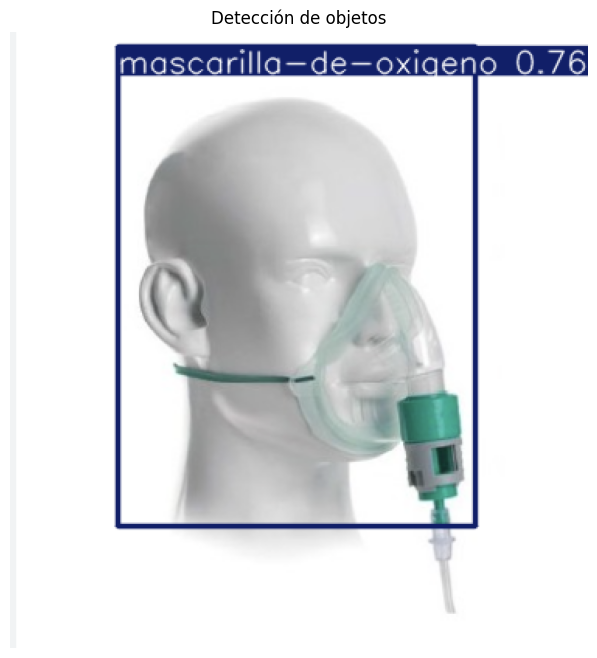

In [12]:
#---APARTADO PARA ver COMO SE COMPORTA EL MODELO CON IMAGENES REALES

# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train/weights/best.pt')

#IMAGEN EXTERNA DE ............[MASCARILLA DE OXIGENO]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/M_oxixgeno.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)




image 1/1 /content/IMAGENES_EXTERNAS/Mascarilla.png: 608x640 1 mascarilla, 71.1ms
Speed: 3.5ms preprocess, 71.1ms inference, 0.6ms postprocess per image at shape (1, 3, 608, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       ...,

       [[206, 210, 188],
        [203, 207,

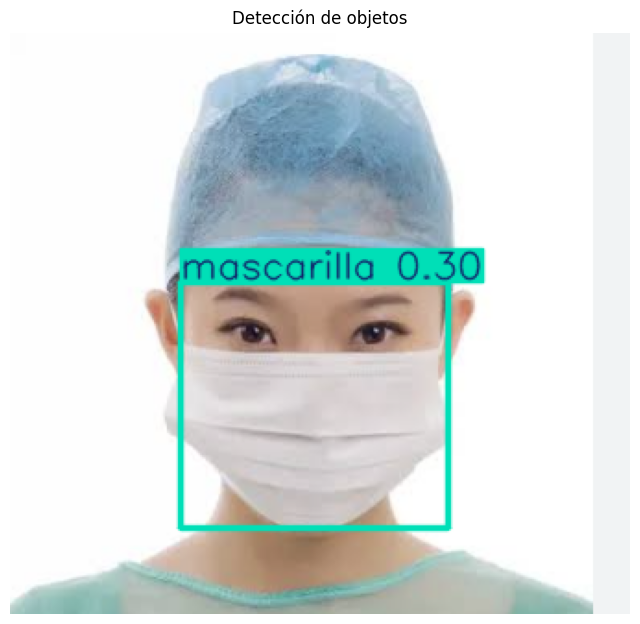

In [13]:
#IMAGEN EXTERNA DE ............[MASCARILLA NORAML]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/Mascarilla.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/Tijera_Recta.png: 640x544 1 Tijera_recta, 2 bisturis, 62.1ms
Speed: 2.8ms preprocess, 62.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[168, 128, 116],
        [164, 124, 113],
        [163, 122, 110],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[165, 125, 114],
        [162, 122, 111],
        [160, 120, 108],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[164, 124, 112],
        [161, 121, 109],
        [158, 119, 106],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       ...,

       [[255, 255, 255],
  

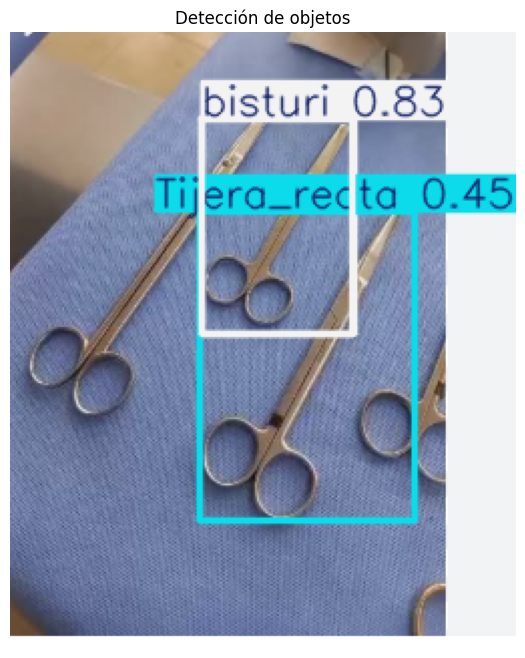

In [14]:
#IMAGEN EXTERNA DE ............[TIJERA RECTA]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/Tijera_Recta.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/bisturi.png: 640x640 (no detections), 11.6ms
Speed: 3.2ms preprocess, 11.6ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[189, 156,  95],
        [189, 156,  95],
        [189, 156,  95],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[189, 156,  95],
        [188, 155,  94],
        [188, 155,  94],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[188, 155,  94],
        [188, 155,  94],
        [188, 155,  94],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       ...,

       [[255, 255, 255],
        [255, 255,

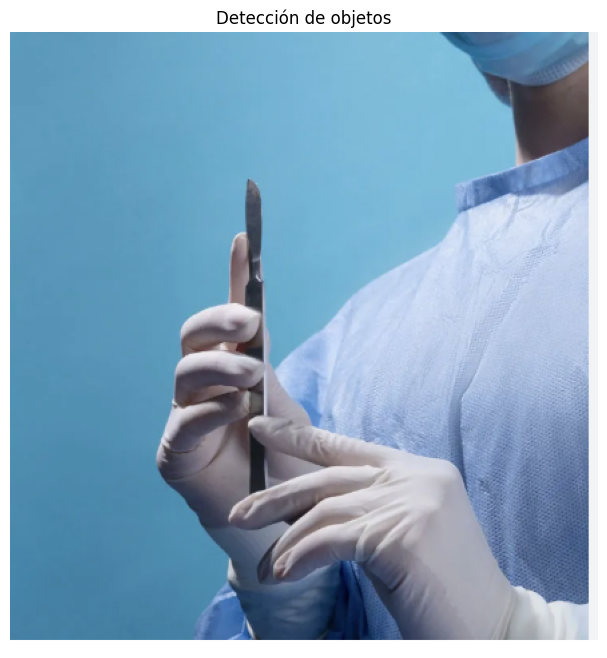

In [15]:
#IMAGEN EXTERNA DE ............[BISTURI]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/bisturi.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/BISTURI2.png: 576x640 (no detections), 63.9ms
Speed: 3.7ms preprocess, 63.9ms inference, 0.4ms postprocess per image at shape (1, 3, 576, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       ...,

       [[255, 255, 255],
        [255, 255

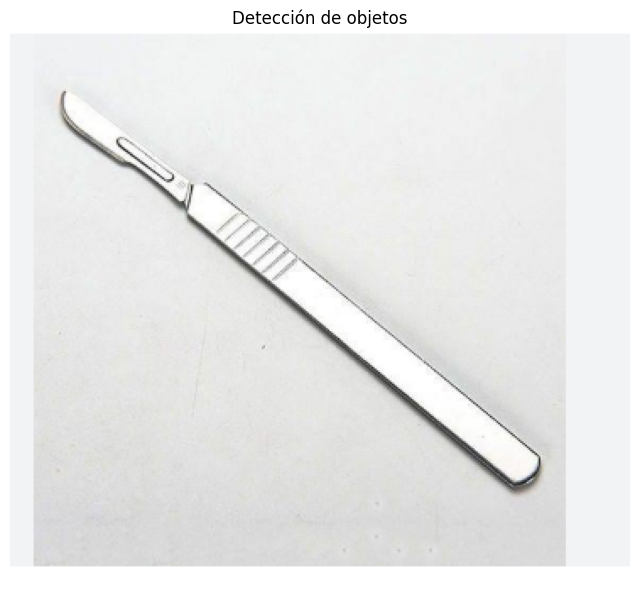

In [16]:
#IMAGEN EXTERNA DE ............[BISTURI2]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/BISTURI2.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/BISTURI3.png: 640x544 (no detections), 16.5ms
Speed: 3.0ms preprocess, 16.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 544)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       [[244, 243, 241],
        [244, 243, 241],
        [244, 243, 241],
        ...,
        [244, 243, 241],
        [244, 243, 241],
        [244, 243, 241]],

       ...,

       [[255, 255, 255],
        [255, 255

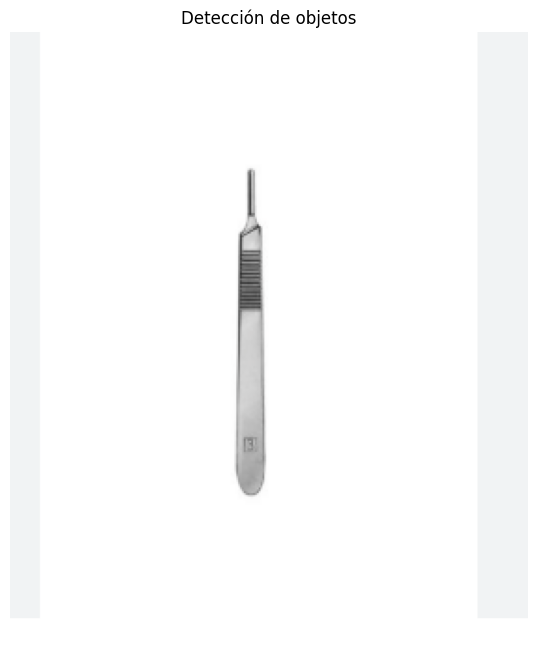

In [17]:
#IMAGEN EXTERNA DE ............[BISTURI3]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/BISTURI3.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/jeringa.png: 640x640 1 Jeringa, 12.0ms
Speed: 2.5ms preprocess, 12.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],

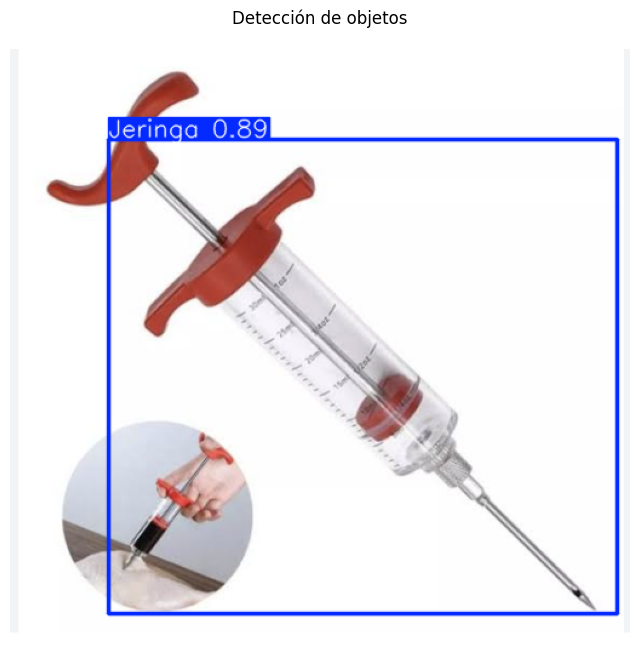

In [18]:
#IMAGEN EXTERNA DE ............[jERINGA]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/jeringa.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/BISTURI3_FONDE NEGRO.png: 448x640 1 bisturi, 60.2ms
Speed: 2.7ms preprocess, 60.2ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [252, 252, 252],
        [252, 252, 252],
        [252, 252, 252]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [252, 252, 252],
        [252, 252, 252],
        [252, 252, 252]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [252, 252, 252],
        [252, 252, 252],
        [252, 252, 252]],

       ...,

       [[  0,   0,   0],
        [  

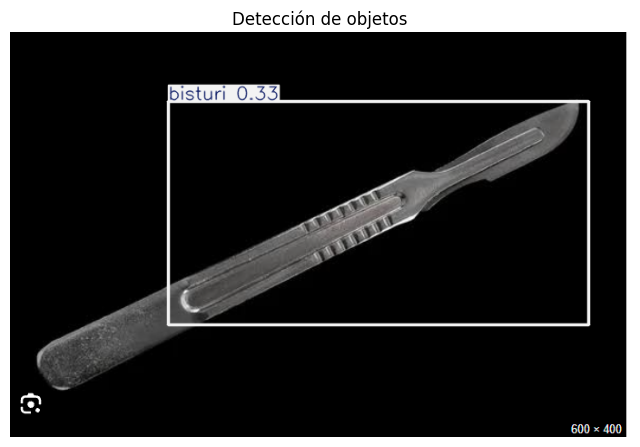

In [19]:
#IMAGEN EXTERNA DE ............[bisturi fondo negro]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/BISTURI3_FONDE NEGRO.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/IMAGENES_EXTERNAS/mascarilla2.png: 544x640 1 mascarilla, 96.2ms
Speed: 2.6ms preprocess, 96.2ms inference, 0.9ms postprocess per image at shape (1, 3, 544, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Jeringa', 1: 'Tijera_recta', 2: 'bisturi', 3: 'mascarilla', 4: 'mascarilla-de-oxigeno'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[183, 194, 207],
        [183, 194

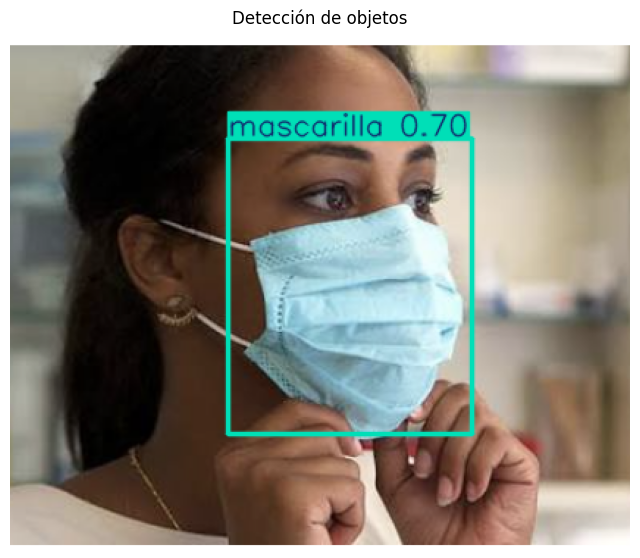

In [20]:
#IMAGEN EXTERNA DE ............[mascarilla 222]
# Ruta de la imagen
image_path = '/content/IMAGENES_EXTERNAS/mascarilla2.png'

# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)